<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20ECO001b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

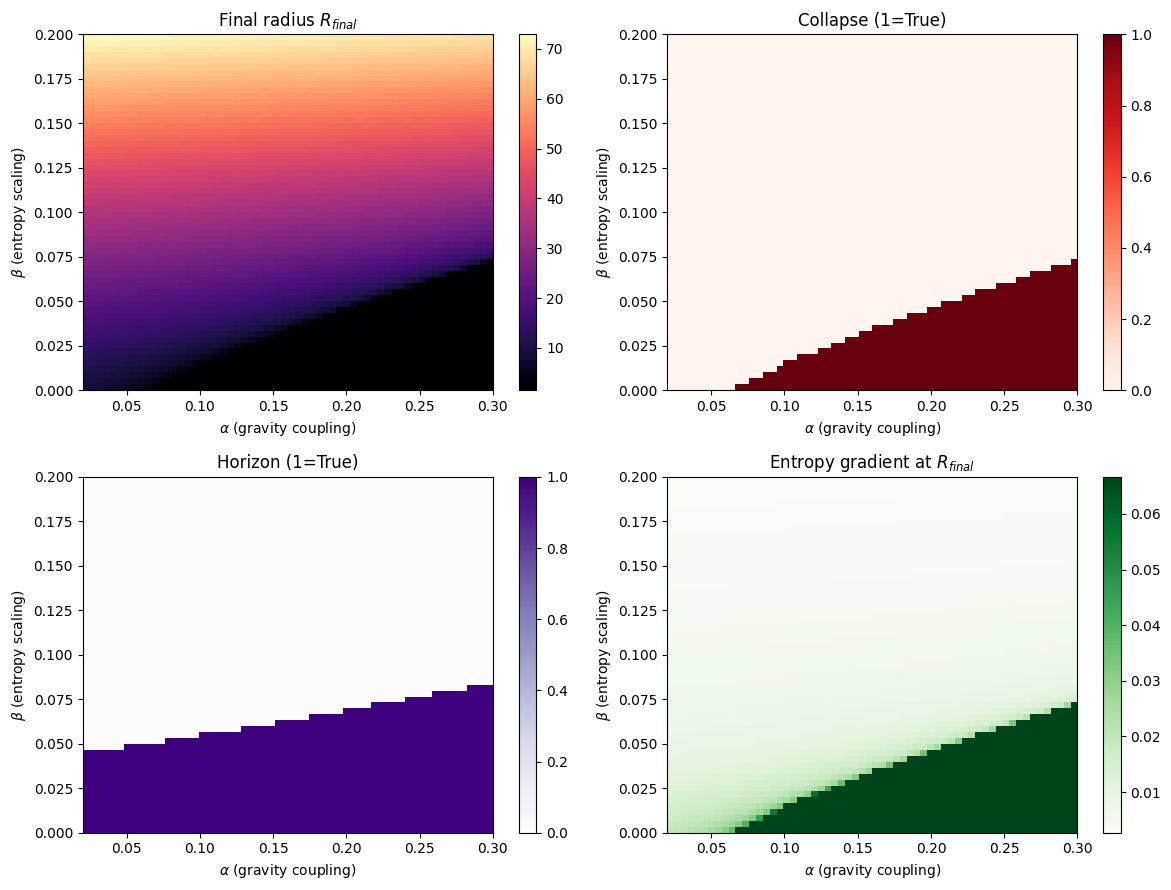

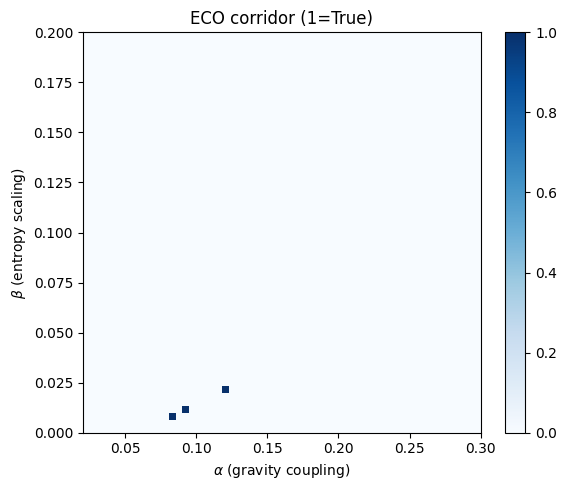

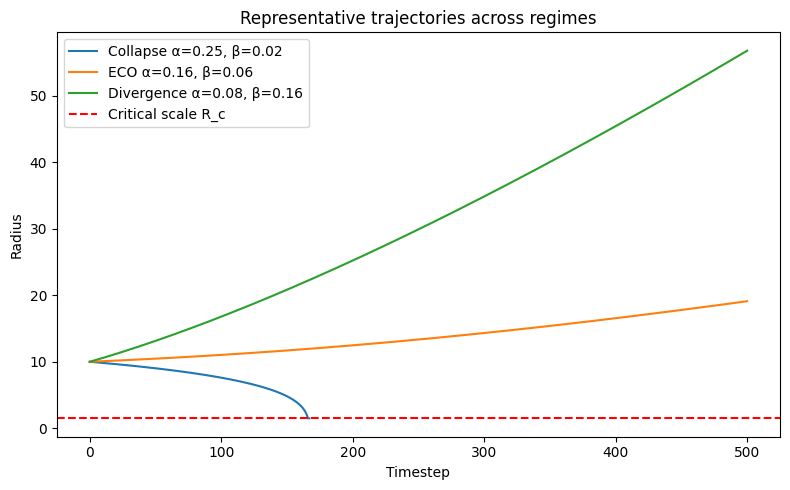

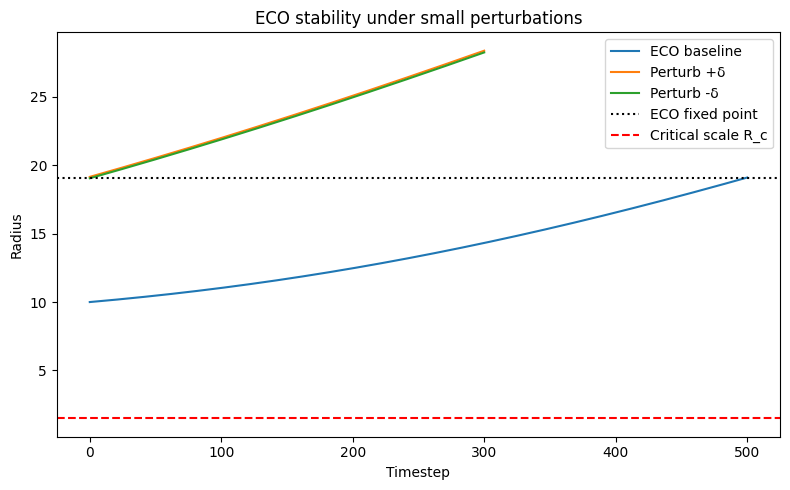

Counts across α–β grid:
  Collapse:  601
  Diverge:   2804
  ECO:       3


In [1]:
# ECO001: Entropic Collapse — α–β sweep
# Reproducible, self-contained, Colab-ready

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Parameters (feel free to edit)
# ----------------------------
M = 10.0            # enclosed mass
R0 = 10.0           # initial radius
R_c = 1.5           # critical collapse scale
alpha_min, alpha_max, n_alpha = 0.02, 0.30, 60
beta_min,  beta_max,  n_beta  = 0.00, 0.20, 60
gamma = 0.20        # entropy coefficient
G = 1.0             # gravitational constant (code units)
c = 1.0             # speed of light (code units)
timesteps = 500     # per-trajectory steps
eps_halt = 1e-4     # threshold for numerical halt detection

# ----------------------------
# Entropy model and dynamics
# ----------------------------
def S(R, R_c=R_c, gamma=gamma):
    # Entropy correction term
    return gamma * np.log(1.0 + R / R_c)

def dS_dR(R, R_c=R_c, gamma=gamma):
    # Entropy gradient
    return gamma * (1.0 / (R + R_c)) * (1.0)

def step(R, alpha, beta, M=M):
    # Discrete update rule for radial collapse with entropic resistance
    # R_{t+1} = R_t - alpha * M / R_t^2 + beta * S(R_t)
    return R - alpha * M / (R**2) + beta * S(R)

def v_escape(R, M=M, G=G):
    return np.sqrt(2.0 * G * M / max(R, 1e-12))

# ----------------------------
# Classification criteria
# ----------------------------
def classify_trajectory(R_series):
    R_final = R_series[-1]
    # Collapse if approaches R_c within small margin
    collapsed = (R_final <= R_c * 1.05)
    # Divergence if grows well beyond initial
    diverged = (R_final >= R0 * 1.20)
    # ECO corridor: neither fully collapsed nor diverged, hovering near R_c without crossing
    eco = (not collapsed) and (not diverged) and (R_final <= R0) and (R_final <= 2.0 * R_c)
    return collapsed, diverged, eco, R_final

# ----------------------------
# Sweep grids
# ----------------------------
alphas = np.linspace(alpha_min, alpha_max, n_alpha)
betas  = np.linspace(beta_min,  beta_max,  n_beta)

R_final_grid = np.zeros((n_beta, n_alpha))
collapsed_grid = np.zeros((n_beta, n_alpha), dtype=bool)
diverged_grid  = np.zeros((n_beta, n_alpha), dtype=bool)
eco_grid       = np.zeros((n_beta, n_alpha), dtype=bool)
horizon_grid   = np.zeros((n_beta, n_alpha), dtype=bool)
dS_final_grid  = np.zeros((n_beta, n_alpha))

# ----------------------------
# Main sweep
# ----------------------------
for j, beta in enumerate(betas):
    for i, alpha in enumerate(alphas):
        R = R0
        R_series = [R]
        # simple fixed-step iteration with non-singularity guard
        for t in range(timesteps):
            R_next = step(R, alpha, beta)
            # prevent crossing below critical scale hard-wall (model hypothesis)
            R_next = max(R_next, R_c)
            # numerical halt detection
            if abs(R_next - R) < eps_halt:
                R = R_next
                R_series.append(R)
                break
            R = R_next
            R_series.append(R)

        collapsed, diverged, eco, R_final = classify_trajectory(R_series)
        R_final_grid[j, i] = R_final
        collapsed_grid[j, i] = collapsed
        diverged_grid[j, i]  = diverged
        eco_grid[j, i]       = eco

        # Horizon test: v_esc >= c at final state
        horizon_grid[j, i] = (v_escape(R_final) >= c)

        # Entropy gradient at final state (resistance indicator)
        dS_final_grid[j, i] = dS_dR(R_final)

# ----------------------------
# Visualization helpers
# ----------------------------
def imshow_with_colorbar(ax, data, title, xvals, yvals, cmap='viridis', vmin=None, vmax=None):
    im = ax.imshow(
        data,
        origin='lower',
        extent=[xvals.min(), xvals.max(), yvals.min(), yvals.max()],
        aspect='auto',
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )
    ax.set_xlabel(r'$\alpha$ (gravity coupling)')
    ax.set_ylabel(r'$\beta$ (entropy scaling)')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

# ----------------------------
# Plots: final radius, classes, horizon, entropy gradient
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
imshow_with_colorbar(
    axes[0,0], R_final_grid, 'Final radius $R_{final}$',
    alphas, betas, cmap='magma'
)
imshow_with_colorbar(
    axes[0,1], collapsed_grid.astype(float), 'Collapse (1=True)',
    alphas, betas, cmap='Reds', vmin=0, vmax=1
)
imshow_with_colorbar(
    axes[1,0], horizon_grid.astype(float), 'Horizon (1=True)',
    alphas, betas, cmap='Purples', vmin=0, vmax=1
)
imshow_with_colorbar(
    axes[1,1], dS_final_grid, 'Entropy gradient at $R_{final}$',
    alphas, betas, cmap='Greens'
)
plt.tight_layout()
plt.show()

# ----------------------------
# ECO corridor mask and display
# ----------------------------
fig, ax = plt.subplots(figsize=(6, 5))
imshow_with_colorbar(
    ax, eco_grid.astype(float), 'ECO corridor (1=True)',
    alphas, betas, cmap='Blues', vmin=0, vmax=1
)
plt.tight_layout()
plt.show()

# ----------------------------
# Sample trajectories in distinct regimes
# ----------------------------
def run_trajectory(alpha, beta, steps=timesteps):
    R = R0
    Rs = [R]
    for t in range(steps):
        Rn = step(R, alpha, beta)
        Rn = max(Rn, R_c)  # non-singularity guard
        if abs(Rn - R) < eps_halt:
            Rs.append(Rn)
            break
        R = Rn
        Rs.append(R)
    return np.array(Rs)

# Pick representative points
alpha_collapse, beta_collapse = 0.25, 0.02
alpha_eco,       beta_eco     = 0.16, 0.06
alpha_diverge,   beta_diverge = 0.08, 0.16

traj_c = run_trajectory(alpha_collapse, beta_collapse)
traj_e = run_trajectory(alpha_eco, beta_eco)
traj_d = run_trajectory(alpha_diverge, beta_diverge)

plt.figure(figsize=(8,5))
plt.plot(traj_c, label=f'Collapse α={alpha_collapse}, β={beta_collapse}')
plt.plot(traj_e, label=f'ECO α={alpha_eco}, β={beta_eco}')
plt.plot(traj_d, label=f'Divergence α={alpha_diverge}, β={beta_diverge}')
plt.axhline(R_c, color='r', linestyle='--', label='Critical scale R_c')
plt.xlabel('Timestep')
plt.ylabel('Radius')
plt.title('Representative trajectories across regimes')
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# Stability check: perturb final ECO state
# ----------------------------
def perturb_and_relax(R_final, alpha, beta, delta=0.05, steps=300):
    # small symmetric perturbation around final state
    Rs_up = [R_final + delta]
    R = Rs_up[0]
    for t in range(steps):
        Rn = step(R, alpha, beta)
        Rn = max(Rn, R_c)
        if abs(Rn - R) < eps_halt:
            Rs_up.append(Rn); break
        R = Rn; Rs_up.append(Rn)

    Rs_dn = [max(R_final - delta, R_c)]
    R = Rs_dn[0]
    for t in range(steps):
        Rn = step(R, alpha, beta)
        Rn = max(Rn, R_c)
        if abs(Rn - R) < eps_halt:
            Rs_dn.append(Rn); break
        R = Rn; Rs_dn.append(Rn)
    return np.array(Rs_up), np.array(Rs_dn)

# Use ECO point for perturbation test
alpha_test, beta_test = alpha_eco, beta_eco
eco_path = run_trajectory(alpha_test, beta_test)
R_star = eco_path[-1]
up, dn = perturb_and_relax(R_star, alpha_test, beta_test)

plt.figure(figsize=(8,5))
plt.plot(eco_path, label='ECO baseline')
plt.plot(np.arange(len(up)), up, label='Perturb +δ')
plt.plot(np.arange(len(dn)), dn, label='Perturb -δ')
plt.axhline(R_star, color='k', linestyle=':', label='ECO fixed point')
plt.axhline(R_c, color='r', linestyle='--', label='Critical scale R_c')
plt.xlabel('Timestep')
plt.ylabel('Radius')
plt.title('ECO stability under small perturbations')
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# Summary counts
# ----------------------------
n_collapse = int(collapsed_grid.sum())
n_diverge  = int(diverged_grid.sum())
n_eco      = int(eco_grid.sum())
print(f'Counts across α–β grid:')
print(f'  Collapse:  {n_collapse}')
print(f'  Diverge:   {n_diverge}')
print(f'  ECO:       {n_eco}')
